# Fluid Mechanics — Chapter 2: Visualizations

Companion notebook for Ch. 2 (*Elementary Viscous Flow*) problem-solution slides.

| Problem | Visualization | Figure |
|---------|---------------|--------|
| 2.3 | Poiseuille flow profiles | `fig_2_3_poiseuille.png` |
| 2.4 | Two-layer inclined-plane flow | `fig_2_4_two_layer.png` |
| 2.6 | Wall-driven flow with suction (Fig. 2.16) | `fig_2_6_suction.png` |
| 2.7 | Stokes oscillating boundary layer | `fig_2_7_stokes.png` |
| 2.10 | Viscous decay of a line vortex | `fig_2_10_vortex.png` |
| 2.14 | Hiemenz stagnation-point flow (Fig. 2.17) | `fig_2_14_hiemenz.png` |
| 2.15 | Stagnation flow with flat plate (Fig. 2.18) | `fig_2_15_plate.png` |

All figures saved to `../figures/` for use in the Quarto slides.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from pathlib import Path

FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12,
    'axes.titlesize': 13, 'axes.labelsize': 12,
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
})
print(f'Figures will be saved to: {FIG_DIR.resolve()}')


Figures will be saved to: /figures


---
## Problem 2.3 — Poiseuille Flow

**Plane channel** ($y=\pm h$): $u(y) = \dfrac{P}{2\mu}(h^2 - y^2)$

**Circular pipe** ($r \leq a$): $u_z(r) = \dfrac{P}{4\mu}(a^2-r^2)$, $Q = \dfrac{\pi P a^4}{8\mu}$


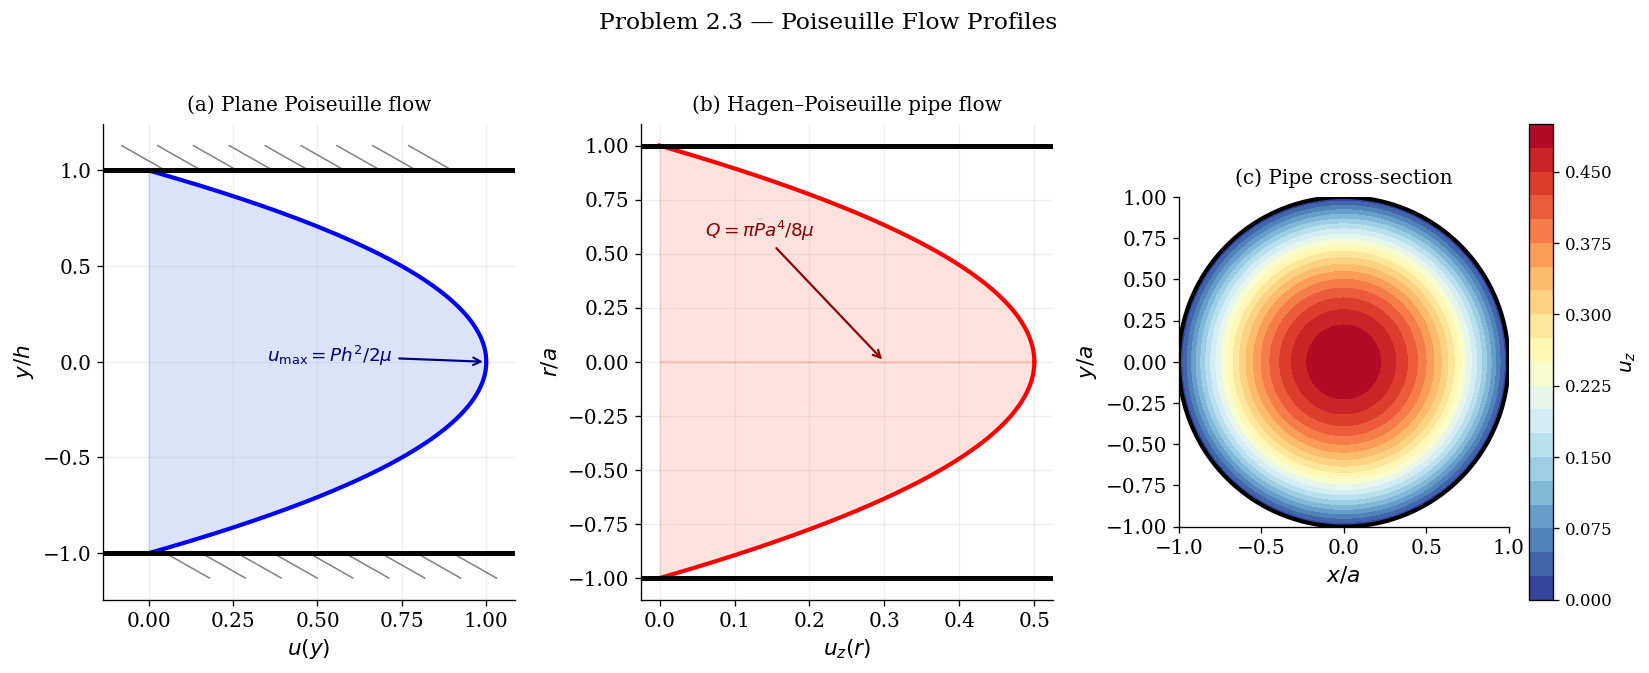

Saved: fig_2_3_poiseuille.png


In [2]:
mu, P = 1.0, 2.0
fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))

# (a) Plane channel: u vs y
ax = axes[0]
h = 1.0
y = np.linspace(-h, h, 300)
u = P/(2*mu) * (h**2 - y**2)
ax.plot(u, y, 'b-', lw=2.5)
ax.fill_betweenx(y, 0, u, alpha=0.18, color='royalblue')
ax.axhline(-h, color='k', lw=3); ax.axhline(h, color='k', lw=3)
for yi, sgn in [(-h, -1), (h, 1)]:
    for xi in np.linspace(0.05, u.max()*0.9, 9):
        ax.plot([xi, xi-0.13*sgn], [yi, yi+0.13*sgn], 'k-', lw=0.9, alpha=0.5)
ax.annotate(r'$u_{\rm max}=Ph^2/2\mu$', xy=(u.max(), 0),
            xytext=(u.max()*0.35, 0.0), fontsize=11,
            arrowprops=dict(arrowstyle='->', color='navy', lw=1.3), color='navy')
ax.set_xlabel('$u(y)$', fontsize=13); ax.set_ylabel('$y/h$', fontsize=13)
ax.set_title('(a) Plane Poiseuille flow', fontsize=12, pad=8)
ax.grid(True, alpha=0.2)

# (b) Pipe: u_z vs r
ax = axes[1]
a = 1.0
r = np.linspace(0, a, 300)
uz = P/(4*mu) * (a**2 - r**2)
ax.plot(uz, r, 'r-', lw=2.5); ax.plot(uz, -r, 'r-', lw=2.5)
ax.fill_betweenx(r,  0, uz, alpha=0.18, color='tomato')
ax.fill_betweenx(-r, 0, uz, alpha=0.18, color='tomato')
ax.axhline(-a, color='k', lw=3); ax.axhline(a, color='k', lw=3)
ax.annotate(r'$Q=\pi Pa^4/8\mu$', xy=(uz.max()*0.6, 0),
            xytext=(uz.max()*0.12, 0.58), fontsize=11, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.3))
ax.set_xlabel('$u_z(r)$', fontsize=13); ax.set_ylabel('$r/a$', fontsize=13)
ax.set_title('(b) Hagen–Poiseuille pipe flow', fontsize=12, pad=8)
ax.grid(True, alpha=0.2)

# (c) Pipe cross-section 2D colour map
ax = axes[2]
x2 = np.linspace(-a, a, 200)
X2, Y2 = np.meshgrid(x2, x2)
R2 = np.sqrt(X2**2 + Y2**2)
UZ2 = np.where(R2 <= a, P/(4*mu)*(a**2-R2**2), np.nan)
cf = ax.contourf(X2, Y2, UZ2, levels=20, cmap='RdYlBu_r')
cbar = plt.colorbar(cf, ax=ax, label='$u_z$')
cbar.ax.tick_params(labelsize=10)
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(a*np.cos(theta), a*np.sin(theta), 'k-', lw=2.5)
ax.set_aspect('equal')
ax.set_xlabel('$x/a$', fontsize=13); ax.set_ylabel('$y/a$', fontsize=13)
ax.set_title('(c) Pipe cross-section', fontsize=12, pad=8)

plt.suptitle('Problem 2.3 — Poiseuille Flow Profiles', fontsize=14, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_2_3_poiseuille.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_2_3_poiseuille.png')


---
## Problem 2.4 — Two-Layer Inclined-Plane Flow

$$u_1(y) = \left[(h_1+h_2)y - \tfrac{1}{2}y^2\right]\frac{g\sin\alpha}{\nu_1}$$

$u_1$ depends on $h_2$ but **not** on $\mu_2$.


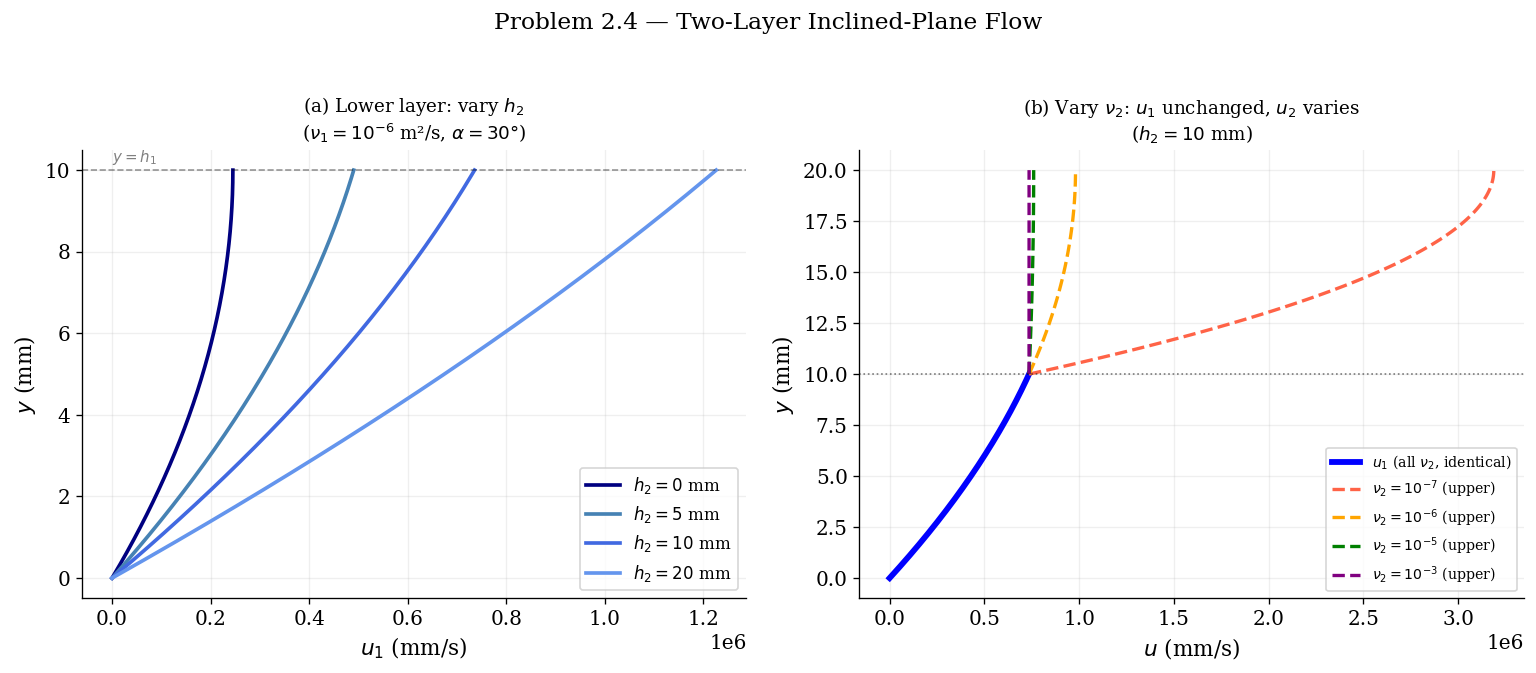

Saved: fig_2_4_two_layer.png


In [3]:
g = 9.81; alpha = np.radians(30)
nu1 = 1e-6; h1 = 0.01
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: vary h2 — show u1 increases with h2
ax = axes[0]
y1 = np.linspace(0, h1, 200)
for h2, col, lab in zip([0, 0.005, 0.01, 0.02],
                         ['navy','steelblue','royalblue','cornflowerblue'],
                         [r'$h_2=0$ mm', r'$h_2=5$ mm',
                          r'$h_2=10$ mm', r'$h_2=20$ mm']):
    u1 = ((h1+h2)*y1 - 0.5*y1**2) * g*np.sin(alpha)/nu1
    ax.plot(u1*1e3, y1*1e3, color=col, lw=2.2, label=lab)
ax.axhline(h1*1e3, color='k', lw=1, ls='--', alpha=0.4)
ax.text(ax.get_xlim()[0] if ax.get_xlim()[0]>0 else 0.5,
        h1*1e3+0.2, '$y=h_1$', fontsize=9, color='gray')
ax.set_xlabel('$u_1$ (mm/s)', fontsize=13); ax.set_ylabel('$y$ (mm)', fontsize=13)
ax.set_title('(a) Lower layer: vary $h_2$\n'
             r'($\nu_1=10^{-6}$ m²/s, $\alpha=30°$)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

# Right: vary nu2 — u1 identical for all nu2
ax = axes[1]
h2 = 0.01
y1 = np.linspace(0, h1, 200)
y2 = np.linspace(h1, h1+h2, 100)
u1 = ((h1+h2)*y1 - 0.5*y1**2) * g*np.sin(alpha)/nu1
ax.plot(u1*1e3, y1*1e3, 'b-', lw=3.5, label=r'$u_1$ (all $\nu_2$, identical)')
u1_h1 = ((h1+h2)*h1 - 0.5*h1**2)*g*np.sin(alpha)/nu1
nu2_vals  = [1e-7, 1e-6, 1e-5, 1e-3]
nu2_cols  = ['tomato','orange','green','purple']
nu2_labs  = [r'$\nu_2=10^{-7}$', r'$\nu_2=10^{-6}$',
             r'$\nu_2=10^{-5}$', r'$\nu_2=10^{-3}$']
for nu2, col, lab in zip(nu2_vals, nu2_cols, nu2_labs):
    u2 = u1_h1 + (g*np.sin(alpha)/nu2)*((h1+h2)*(y2-h1) - 0.5*(y2**2-h1**2))
    ax.plot(u2*1e3, y2*1e3, color=col, lw=2, ls='--', label=lab+' (upper)')
ax.axhline(h1*1e3, color='k', lw=1, ls=':', alpha=0.5)
ax.set_xlabel('$u$ (mm/s)', fontsize=13); ax.set_ylabel('$y$ (mm)', fontsize=13)
ax.set_title('(b) Vary $\\nu_2$: $u_1$ unchanged, $u_2$ varies\n'
             r'($h_2=10$ mm)', fontsize=11)
ax.legend(fontsize=8.5, loc='lower right')
ax.grid(True, alpha=0.2)

plt.suptitle('Problem 2.4 — Two-Layer Inclined-Plane Flow', fontsize=14, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_2_4_two_layer.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_2_4_two_layer.png')


---
## Problem 2.6 — Wall-Driven Channel Flow with Suction

$$u(y) = U\left(\frac{e^{-v_0 y/\nu}-e^{-v_0 h/\nu}}{1-e^{-v_0 h/\nu}}\right), \quad v=-v_0$$

Reproduces **Fig. 2.16** from Acheson.


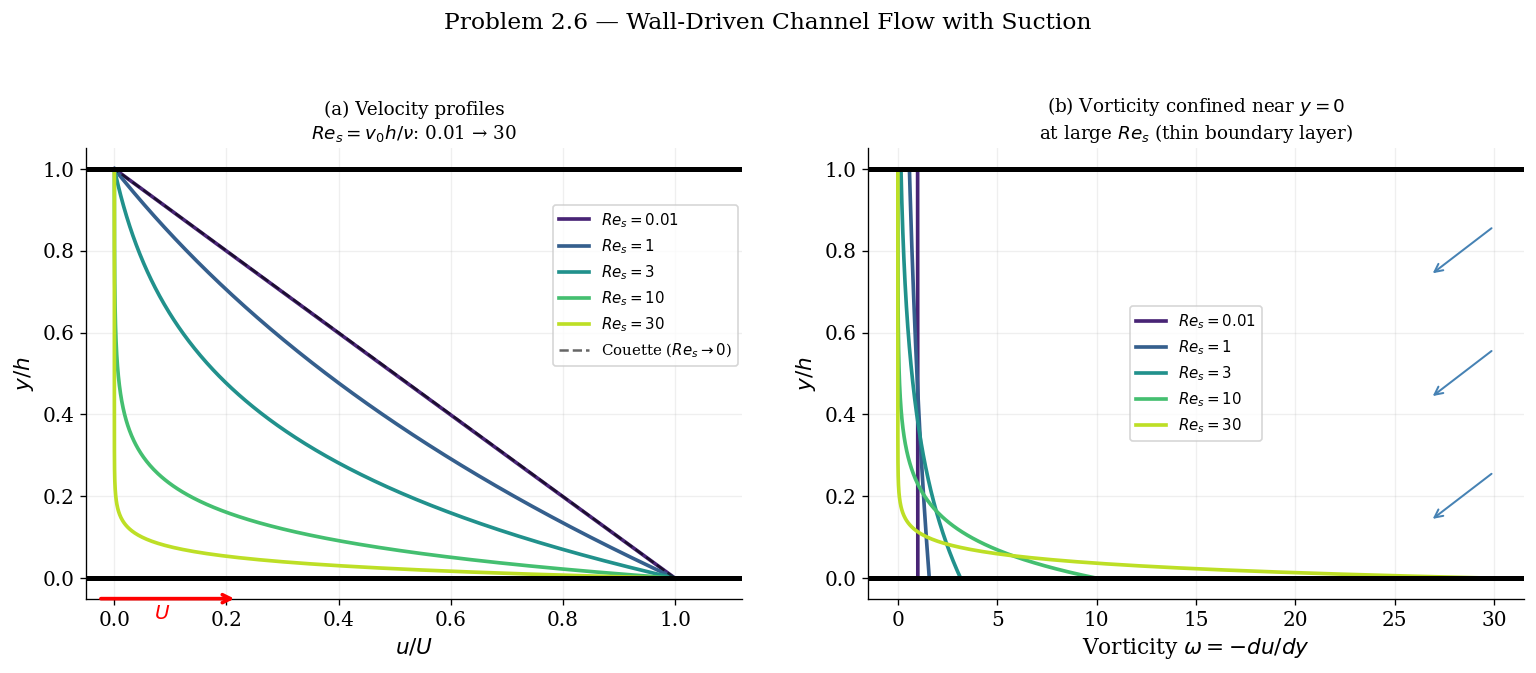

Saved: fig_2_6_suction.png


In [4]:
U = 1.0; h = 1.0; nu = 1.0
y = np.linspace(0, h, 400)
Re_s_vals = [0.01, 1, 3, 10, 30]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(Re_s_vals)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: velocity profiles
ax = axes[0]
for Re_s, col in zip(Re_s_vals, colors):
    v0 = Re_s * nu / h
    exp_h = np.exp(-v0*h/nu)
    u = U * (np.exp(-v0*y/nu) - exp_h) / (1 - exp_h)
    ax.plot(u, y, color=col, lw=2.2, label=f'$Re_s={Re_s}$')
ax.plot([U, 0], [0, h], 'k--', lw=1.5, alpha=0.6,
        label=r'Couette ($Re_s\to 0$)')
ax.axhline(0, color='k', lw=3); ax.axhline(h, color='k', lw=3)
# Wall motion arrow
ax.annotate('', xy=(0.22, -0.05), xytext=(-0.03, -0.05),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.2))
ax.text(0.07, -0.1, '$U$', fontsize=12, color='red', fontweight='bold')
ax.set_xlabel('$u/U$', fontsize=13); ax.set_ylabel('$y/h$', fontsize=13)
ax.set_title('(a) Velocity profiles\n'
             r'$Re_s = v_0 h/\nu$: 0.01 → 30', fontsize=11)
ax.legend(fontsize=9, bbox_to_anchor=(0.7, 0.5))
ax.set_xlim(-0.05, 1.12)
ax.grid(True, alpha=0.2)

# Right: vorticity — confinement near y=0
ax = axes[1]
for Re_s, col in zip(Re_s_vals, colors):
    v0 = Re_s * nu / h
    exp_h = np.exp(-v0*h/nu)
    dudy = U * (-v0/nu) * np.exp(-v0*y/nu) / (1 - exp_h)
    ax.plot(-dudy, y, color=col, lw=2.2, label=f'$Re_s={Re_s}$')
ax.axhline(0, color='k', lw=3); ax.axhline(h, color='k', lw=3)
# Suction arrows
for ya in [0.2, 0.5, 0.8]:
    ax.annotate('', xy=(ax.get_xlim()[1]*0.85 if True else 30, ya-0.06),
                xytext=(30, ya+0.06),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))
ax.set_xlabel(r'Vorticity $\omega = -du/dy$', fontsize=13)
ax.set_ylabel('$y/h$', fontsize=13)
ax.set_title('(b) Vorticity confined near $y=0$\n'
             'at large $Re_s$ (thin boundary layer)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

plt.suptitle('Problem 2.6 — Wall-Driven Channel Flow with Suction', fontsize=14, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_2_6_suction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_2_6_suction.png')


---
## Problem 2.7 — Stokes' Oscillating Boundary Layer

$$u(y,t) = U e^{-ky}\cos(ky-\omega t), \quad k=(\omega/2\nu)^{1/2}$$


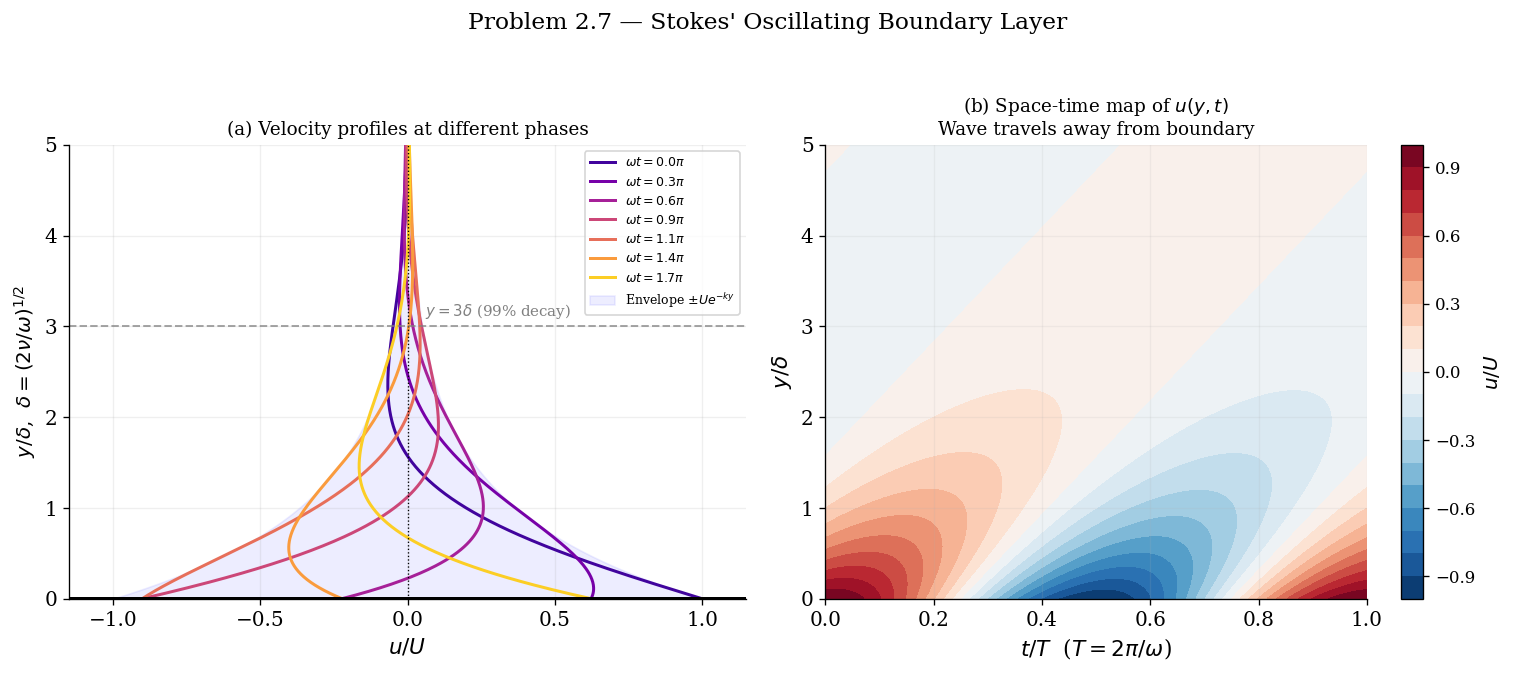

Saved: fig_2_7_stokes.png  (delta=0.0564 m, k=17.72 m⁻¹)


In [5]:
U = 1.0; omega = 2*np.pi; nu = 1e-2
k = np.sqrt(omega/(2*nu)); delta = 1/k
y = np.linspace(0, 5*delta, 500)
T = 2*np.pi/omega

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: velocity profiles at 6 phases
ax = axes[0]
t_vals = np.linspace(0, T, 7, endpoint=False)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_vals)))
for t, col in zip(t_vals, colors):
    u = U * np.exp(-k*y) * np.cos(k*y - omega*t)
    ax.plot(u, y/delta, color=col, lw=1.8,
            label=f'$\\omega t={omega*t/np.pi:.1f}\\pi$')
ax.fill_betweenx(y/delta, -U*np.exp(-k*y), U*np.exp(-k*y),
                 alpha=0.07, color='blue', label=r'Envelope $\pm Ue^{-ky}$')
ax.axvline(0, color='k', lw=0.8, ls=':')
ax.axhline(0, color='k', lw=3)
ax.axhline(3, color='gray', lw=1.2, ls='--', alpha=0.7)
ax.text(0.06, 3.12, r'$y=3\delta$ (99% decay)', fontsize=9, color='gray')
ax.set_xlabel('$u/U$', fontsize=13)
ax.set_ylabel(r'$y/\delta$,  $\delta=(2\nu/\omega)^{1/2}$', fontsize=12)
ax.set_title('(a) Velocity profiles at different phases', fontsize=11)
ax.legend(fontsize=7.5, loc='upper right')
ax.set_ylim(0, 5); ax.set_xlim(-1.15, 1.15)
ax.grid(True, alpha=0.2)

# Right: space-time map with t/T axis
ax = axes[1]
t_arr = np.linspace(0, T, 200)
Y_arr = np.linspace(0, 5*delta, 200)
T2, Y2 = np.meshgrid(t_arr, Y_arr)
U2 = U * np.exp(-k*Y2) * np.cos(k*Y2 - omega*T2)
cf = ax.contourf(t_arr/T, Y_arr/delta, U2,
                 levels=np.linspace(-1, 1, 21), cmap='RdBu_r')
cbar = plt.colorbar(cf, ax=ax, label='$u/U$')
cbar.ax.tick_params(labelsize=10)
ax.set_xlabel('$t/T$  ($T=2\\pi/\\omega$)', fontsize=13)
ax.set_ylabel(r'$y/\delta$', fontsize=13)
ax.set_title('(b) Space-time map of $u(y,t)$\n'
             r'Wave travels away from boundary', fontsize=11)
ax.grid(True, alpha=0.15)

plt.suptitle('Problem 2.7 — Stokes\' Oscillating Boundary Layer', fontsize=14, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_2_7_stokes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig_2_7_stokes.png  (delta={delta:.4f} m, k={k:.2f} m⁻¹)')


---
## Problem 2.10 — Viscous Decay of a Line Vortex

$$u_\theta = \frac{\Gamma_0}{2\pi r}(1-e^{-r^2/4\nu t}), \quad\omega_z = \frac{\Gamma_0}{4\pi\nu t}e^{-r^2/4\nu t}$$


t=0.1: ∫ω_z dA = 0.9990  (should be Γ₀=1.0)
t=0.5: ∫ω_z dA = 0.9998  (should be Γ₀=1.0)
t=2.0: ∫ω_z dA = 0.9999  (should be Γ₀=1.0)
t=8.0: ∫ω_z dA = 1.0000  (should be Γ₀=1.0)


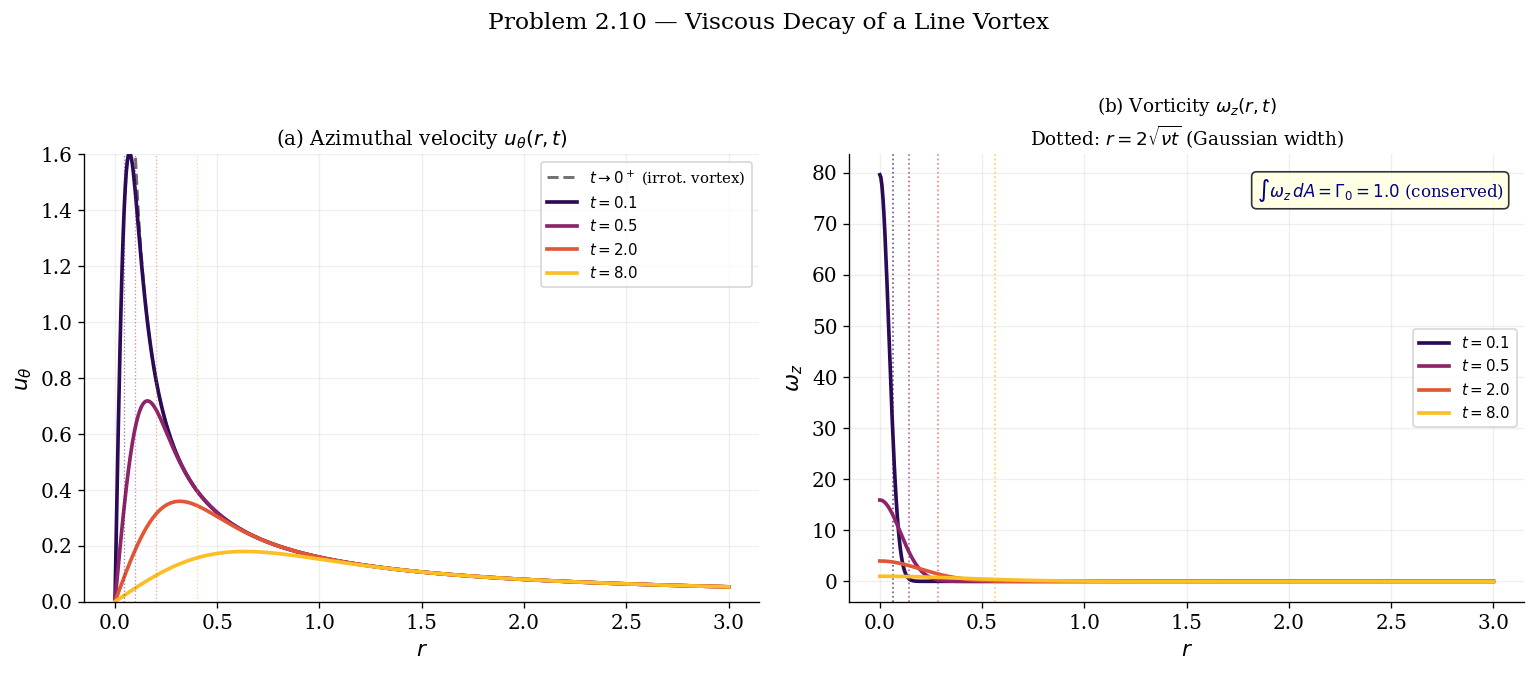

Saved: fig_2_10_vortex.png


In [6]:
Gamma0 = 1.0; nu = 0.01
r = np.linspace(1e-4, 3.0, 600)
t_vals = [0.1, 0.5, 2.0, 8.0]
colors = plt.cm.inferno(np.linspace(0.15, 0.85, len(t_vals)))

# Verify circulation conservation
from scipy.integrate import trapezoid
for t in t_vals:
    omega_z = Gamma0/(4*np.pi*nu*t) * np.exp(-r**2/(4*nu*t))
    circ = trapezoid(omega_z * 2*np.pi*r, r)
    print(f't={t}: ∫ω_z dA = {circ:.4f}  (should be Γ₀={Gamma0})')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: azimuthal velocity
ax = axes[0]
ax.plot(r, Gamma0/(2*np.pi*r), 'k--', lw=1.8, alpha=0.55,
        label=r'$t\to 0^+$ (irrot. vortex)')
for t, col in zip(t_vals, colors):
    u_th = Gamma0/(2*np.pi*r) * (1 - np.exp(-r**2/(4*nu*t)))
    ax.plot(r, u_th, color=col, lw=2.2, label=f'$t={t}$')
ax.set_xlabel('$r$', fontsize=13); ax.set_ylabel(r'$u_\theta$', fontsize=13)
ax.set_title('(a) Azimuthal velocity $u_\\theta(r,t)$', fontsize=12)
ax.legend(fontsize=9); ax.set_ylim(0, 1.6)
ax.grid(True, alpha=0.2)
# Mark core radius r* where u_theta is maximum
for t, col in zip(t_vals, colors):
    r_star = np.sqrt(2*nu*t)   # approximate max from du_theta/dr=0
    ax.axvline(r_star, color=col, lw=0.8, ls=':', alpha=0.5)

# Right: vorticity with Gaussian width markers
ax = axes[1]
for t, col in zip(t_vals, colors):
    omega_z = Gamma0/(4*np.pi*nu*t) * np.exp(-r**2/(4*nu*t))
    ax.plot(r, omega_z, color=col, lw=2.2, label=f'$t={t}$')
    ax.axvline(2*np.sqrt(nu*t), color=col, lw=1.0, ls=':', alpha=0.7)
ax.set_xlabel('$r$', fontsize=13)
ax.set_ylabel(r'$\omega_z$', fontsize=13)
ax.set_title('(b) Vorticity $\\omega_z(r,t)$\n'
             r'Dotted: $r=2\sqrt{\nu t}$ (Gaussian width)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
# Annotation at safe position (top-right)
ax.text(0.97, 0.95, f'$\\int\\omega_z\\,dA = \\Gamma_0 = {Gamma0}$ (conserved)',
        transform=ax.transAxes, fontsize=10, color='navy', ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Problem 2.10 — Viscous Decay of a Line Vortex', fontsize=14, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_2_10_vortex.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_2_10_vortex.png')


---
## Problem 2.14 — Hiemenz Stagnation-Point Flow (Fig. 2.17)

Solve numerically: $f''' + ff'' + 1 - f'^2 = 0$, $f(0)=f'(0)=0$, $f'(\infty)=1$


In [7]:
def falkner_skan(eta, y):
    f, fp, fpp = y
    return [fp, fpp, fp**2 - f*fpp - 1]

def shoot(fpp0, eta_max=10):
    return solve_ivp(falkner_skan, [0, eta_max], [0, 0, fpp0],
                     method="Radau", dense_output=True,
                     rtol=1e-8, atol=1e-10)

fpp0_star = brentq(lambda c: shoot(c).y[2,-1], 1.23, 1.25, xtol=1e-10)
sol = shoot(fpp0_star)
eta = np.linspace(0, 6, 500)
f, fp, fpp = sol.sol(eta)

print(f"f''(0) = {fpp0_star:.6f}")
print(f"f'(3)  = {float(sol.sol(3)[1]):.4f}  (Acheson: 0.998)")
print(f"f''(10)= {sol.y[2,-1]:.3e}")


f''(0) = 1.232588
f'(3)  = 0.9984  (Acheson: 0.998)
f''(10)= 2.392e-14


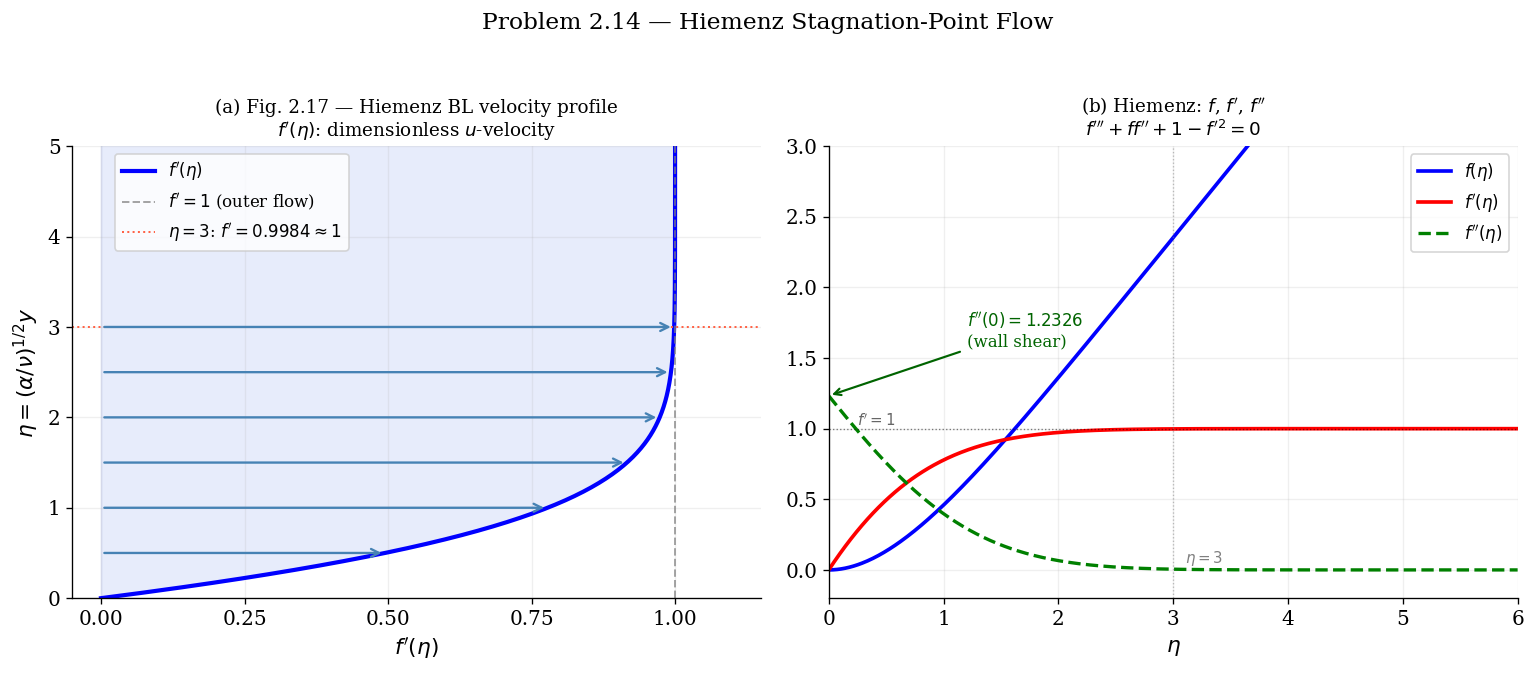

Saved: fig_2_14_hiemenz.png  f'(3)=0.9984


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: f'(eta) -- reproduces Fig. 2.17
ax = axes[0]
ax.plot(fp, eta, 'b-', lw=2.5, label="$f'(\\eta)$")
ax.axvline(1.0, color='gray', lw=1.2, ls='--', alpha=0.7,
           label="$f'=1$ (outer flow)")
fp3_val = float(sol.sol(3)[1])
ax.axhline(3.0, color='tomato', lw=1.2, ls=':',
           label=f"$\\eta=3$: $f'={fp3_val:.4f}\\approx 1$")
ax.fill_betweenx(eta, 0, fp, alpha=0.12, color='royalblue')
# Arrows at uniform eta intervals (like Acheson Fig. 2.17)
for eta_i in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    fp_i = float(sol.sol(eta_i)[1])
    ax.annotate('', xy=(fp_i, eta_i), xytext=(0, eta_i),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.4))
ax.set_xlabel("$f'(\\eta)$", fontsize=13)
ax.set_ylabel(r'$\eta = (\alpha/\nu)^{1/2}y$', fontsize=13)
ax.set_title('(a) Fig. 2.17 — Hiemenz BL velocity profile\n'
             r"$f'(\eta)$: dimensionless $u$-velocity", fontsize=11)
ax.legend(fontsize=10, bbox_to_anchor=(0.05, 0.75))
ax.set_xlim(-0.05, 1.15); ax.set_ylim(0, 5)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.grid(True, alpha=0.2)

# Right: f, f', f'' with annotations
ax = axes[1]
ax.plot(eta, f,   'b-',  lw=2.2, label='$f(\\eta)$')
ax.plot(eta, fp,  'r-',  lw=2.2, label="$f'(\\eta)$")
ax.plot(eta, fpp, 'g--', lw=2.0, label="$f''(\\eta)$")
ax.axhline(1, color='k', lw=0.8, ls=':', alpha=0.5)
ax.axvline(3, color='gray', lw=0.8, ls=':', alpha=0.5)
ax.text(3.1, 0.05, '$\\eta=3$', fontsize=9, color='gray')
ax.text(0.25, 1.02, '$f\'=1$', fontsize=9, color='k', alpha=0.6)
# Annotate f''(0) = initial wall shear
ax.annotate(f"$f''(0)={fpp0_star:.4f}$\n(wall shear)",
            xy=(0, fpp0_star), xytext=(1.2, fpp0_star+0.35),
            fontsize=10, color='darkgreen',
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.3))
ax.set_xlabel('$\\eta$', fontsize=13)
ax.set_title('(b) Hiemenz: $f$, $f\'$, $f\'\'$\n'
             r"$f'''+ff''+1-f'^2=0$", fontsize=11)
ax.legend(fontsize=10); ax.set_xlim(0, 6); ax.set_ylim(-0.2, 3)
ax.grid(True, alpha=0.2)

plt.suptitle('Problem 2.14 — Hiemenz Stagnation-Point Flow', fontsize=14, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_2_14_hiemenz.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: fig_2_14_hiemenz.png  f'(3)={fp3_val:.4f}")


---
## Problem 2.15 — Stagnation Flow with a Flat Plate (Fig. 2.18)

Qualitative sketch: original stagnation flow vs. restructured flow with plate.


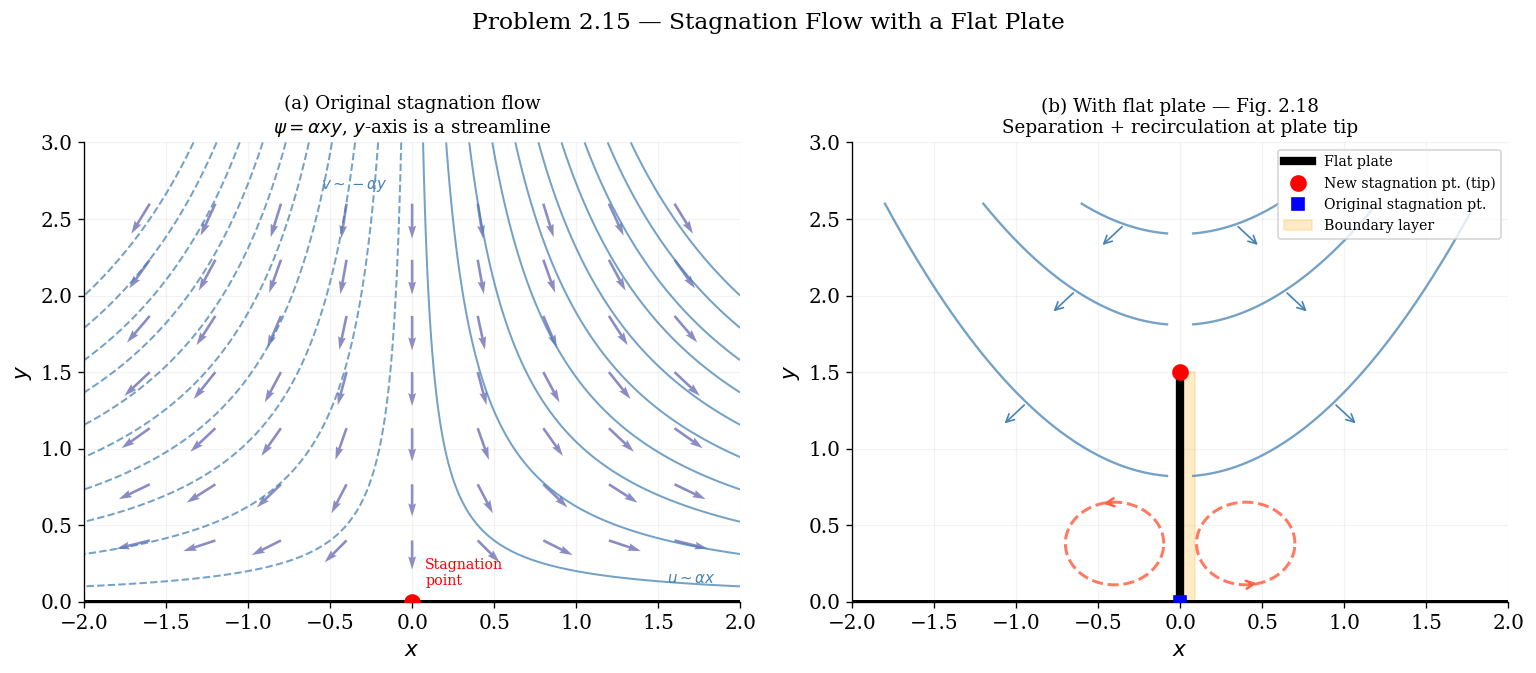

Saved: fig_2_15_plate.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: original stagnation flow (psi = alpha*x*y)
ax = axes[0]
x = np.linspace(-2, 2, 400)
y = np.linspace(0.01, 3, 400)
X, Y = np.meshgrid(x, y)
PSI = X * Y
cs = ax.contour(X, Y, PSI, levels=np.concatenate([
    np.linspace(-4, -0.2, 10), np.linspace(0.2, 4, 10)]),
    colors='steelblue', linewidths=1.2, alpha=0.75)
# Velocity arrows
xq = np.linspace(-1.6, 1.6, 9)
yq = np.linspace(0.4, 2.6, 7)
Xq, Yq = np.meshgrid(xq, yq)
speed = np.sqrt(Xq**2 + Yq**2) + 0.1
ax.quiver(Xq, Yq, Xq/speed, -Yq/speed, alpha=0.45,
          scale=18, width=0.004, color='navy')
ax.axhline(0, color='k', lw=3)
ax.plot(0, 0, 'ro', ms=9, zorder=6)
ax.text(0.08, 0.11, 'Stagnation\npoint', fontsize=8.5, color='red', ha='left')
# Label axes of stagnation flow
ax.text( 1.85, 0.12, r'$u\sim\alpha x$', fontsize=9, color='steelblue', ha='right')
ax.text(-0.15, 2.7,  r'$v\sim-\alpha y$', fontsize=9, color='steelblue', ha='right')
ax.set_xlim(-2, 2); ax.set_ylim(0, 3)
ax.set_xlabel('$x$', fontsize=13); ax.set_ylabel('$y$', fontsize=13)
ax.set_title('(a) Original stagnation flow\n'
             r'$\psi = \alpha xy$, $y$-axis is a streamline', fontsize=11)
ax.grid(True, alpha=0.15)

# Right: flow restructured by flat plate
ax = axes[1]
L = 1.5
ax.plot([0, 0], [0, L], 'k-', lw=5, zorder=5, label='Flat plate')
ax.plot(0, L, 'ro', ms=9, zorder=6, label='New stagnation pt. (tip)')
ax.plot(0, 0, 'bs', ms=7, zorder=6, label='Original stagnation pt.')

# Incoming streamlines bending around plate tip
for x0 in [-1.8, -1.2, -0.6, 0.6, 1.2, 1.8]:
    sgn = np.sign(x0)
    xs = np.linspace(x0, sgn*0.08, 200)
    ys = L + (xs**2 - x0**2)*0.55 + 1.1
    mask = ys >= 0
    ax.plot(xs[mask], ys[mask], color='steelblue', lw=1.4, alpha=0.75)
    # Arrow on streamline
    mid = len(xs)//2
    ax.annotate('', xy=(xs[mid]+sgn*0.15, ys[mid]-0.15),
                xytext=(xs[mid], ys[mid]),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.0))

# Recirculation vortices (counter-rotating pair)
th = np.linspace(0, 2*np.pi, 200)
for cx, cy, rot_dir in [(-0.4, 0.38, 1), (0.4, 0.38, -1)]:
    ax.plot(cx + 0.3*np.cos(th), cy + 0.27*np.sin(th),
            'tomato', lw=1.8, ls='--', alpha=0.85)
    # Arrow showing rotation direction
    th_arr = np.pi/2 * rot_dir
    ax.annotate('',
                xy=(cx + 0.3*np.cos(th_arr+0.3), cy + 0.27*np.sin(th_arr+0.3)),
                xytext=(cx + 0.3*np.cos(th_arr), cy + 0.27*np.sin(th_arr)),
                arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5))

# Boundary layer shading on plate
ax.fill_betweenx([0, L], 0, 0.09, alpha=0.22, color='orange',
                 label='Boundary layer')

ax.axhline(0, color='k', lw=3)
ax.set_xlim(-2, 2); ax.set_ylim(0, 3)
ax.set_xlabel('$x$', fontsize=13); ax.set_ylabel('$y$', fontsize=13)
ax.set_title('(b) With flat plate — Fig. 2.18\n'
             'Separation + recirculation at plate tip', fontsize=11)
ax.legend(fontsize=8.5, loc='upper right')
ax.grid(True, alpha=0.15)

plt.suptitle('Problem 2.15 — Stagnation Flow with a Flat Plate', fontsize=14, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_2_15_plate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_2_15_plate.png')


---
## Summary of saved figures

| File | Problem |
|------|----------|
| `fig_2_3_poiseuille.png` | 2.3 |
| `fig_2_4_two_layer.png` | 2.4 |
| `fig_2_6_suction.png` | 2.6 |
| `fig_2_7_stokes.png` | 2.7 |
| `fig_2_10_vortex.png` | 2.10 |
| `fig_2_14_hiemenz.png` | 2.14 |
| `fig_2_15_plate.png` | 2.15 |


In [10]:
# ── Package all slide figures and download (Colab) ────────────────────────
import zipfile, os

zip_path = Path('ch02_figures.zip')
fig_files = [
    'fig_2_3_poiseuille.png',
    'fig_2_4_two_layer.png',
    'fig_2_6_suction.png',
    'fig_2_7_stokes.png',
    'fig_2_10_vortex.png',
    'fig_2_14_hiemenz.png',
    'fig_2_15_plate.png',
]

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in fig_files:
        fpath = FIG_DIR / fname
        if fpath.exists():
            zf.write(fpath, fname)
            print(f'  added: {fname}  ({fpath.stat().st_size/1024:.0f} KB)')
        else:
            print(f'  MISSING: {fname} — run the cell above first')

total_kb = zip_path.stat().st_size / 1024
print(f'\nZip: {zip_path}  ({total_kb:.0f} KB)')

# Auto-download in Colab
try:
    from google.colab import files
    files.download(str(zip_path))
    print('Download started.')
except ImportError:
    print(f'Not in Colab — file saved locally at: {zip_path.resolve()}')


  added: fig_2_3_poiseuille.png  (179 KB)
  added: fig_2_4_two_layer.png  (142 KB)
  added: fig_2_6_suction.png  (169 KB)
  added: fig_2_7_stokes.png  (157 KB)
  added: fig_2_10_vortex.png  (150 KB)
  added: fig_2_14_hiemenz.png  (123 KB)
  added: fig_2_15_plate.png  (264 KB)

Zip: ch02_figures.zip  (1095 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
